# 02 · The router engine, and what it saves

The estimator is RollingBench §8: a ridge regression per model over a 64-dimensional
frozen feature map, with a LinUCB uncertainty term, closed-form throughout. No gradient
descent, no GPU, no training job — one matrix solve, and rank-one updates as outcomes
arrive.

This notebook answers the commercial question: **routed against one strong model, what
does it cost and what does it deliver?**

In [1]:
import sys; sys.path.insert(0, "..")
from notebooks.nbhelp import load, table, pct, show, md, finding
import numpy as np, pandas as pd

## The dial, not the number

λ_c is the cost weight in §8.7's decision rule, and it is the frontend's cost/quality
control. Quoting a single savings figure without it would be picking a point on a curve
and calling it a result, so here is the whole curve. It reads as "how much quality am I
willing to give up to save the cost of one frontier call".

In [2]:
fr = load("frontier")
sw = pd.DataFrame(fr["sweep"])
view = sw[["lam_cost", "quality", "quality_vs_frontier", "cost_usd",
           "savings_vs_frontier", "score_feasible", "regret_spec", "models_used"]].copy()
view.columns = ["λ_c", "quality", "vs frontier", "cost $", "saved",
                "score (attainable)", "regret (§8.8)", "models used"]
view.style.format({"λ_c": "{:g}", "quality": "{:.4f}", "vs frontier": "{:.1%}",
                   "cost $": "${:.2f}", "saved": "{:.1%}",
                   "score (attainable)": "{:+.3f}", "regret (§8.8)": "{:.3f}"})

,λ_c,quality,vs frontier,cost $,saved,score (attainable),regret (§8.8),models used
0,0,0.7803,100.3%,$31.65,15.8%,+0.676,0.984,10
1,0.01,0.7807,100.3%,$30.56,18.7%,+0.862,0.974,10
2,0.02,0.7796,100.2%,$29.57,21.3%,+0.781,0.973,10
3,0.03,0.7792,100.1%,$28.13,25.2%,+0.899,0.964,10
4,0.04,0.7771,99.9%,$25.28,32.8%,+0.902,0.959,10
5,0.05,0.7732,99.4%,$20.86,44.5%,+0.899,0.954,10
6,0.07,0.7650,98.3%,$13.43,64.3%,+1.055,0.933,10
7,0.1,0.7515,96.6%,$10.41,72.3%,+1.015,0.901,9
8,0.15,0.7282,93.6%,$7.05,81.2%,+0.939,0.832,9
9,0.2,0.7050,90.6%,$4.59,87.8%,+0.850,0.867,9


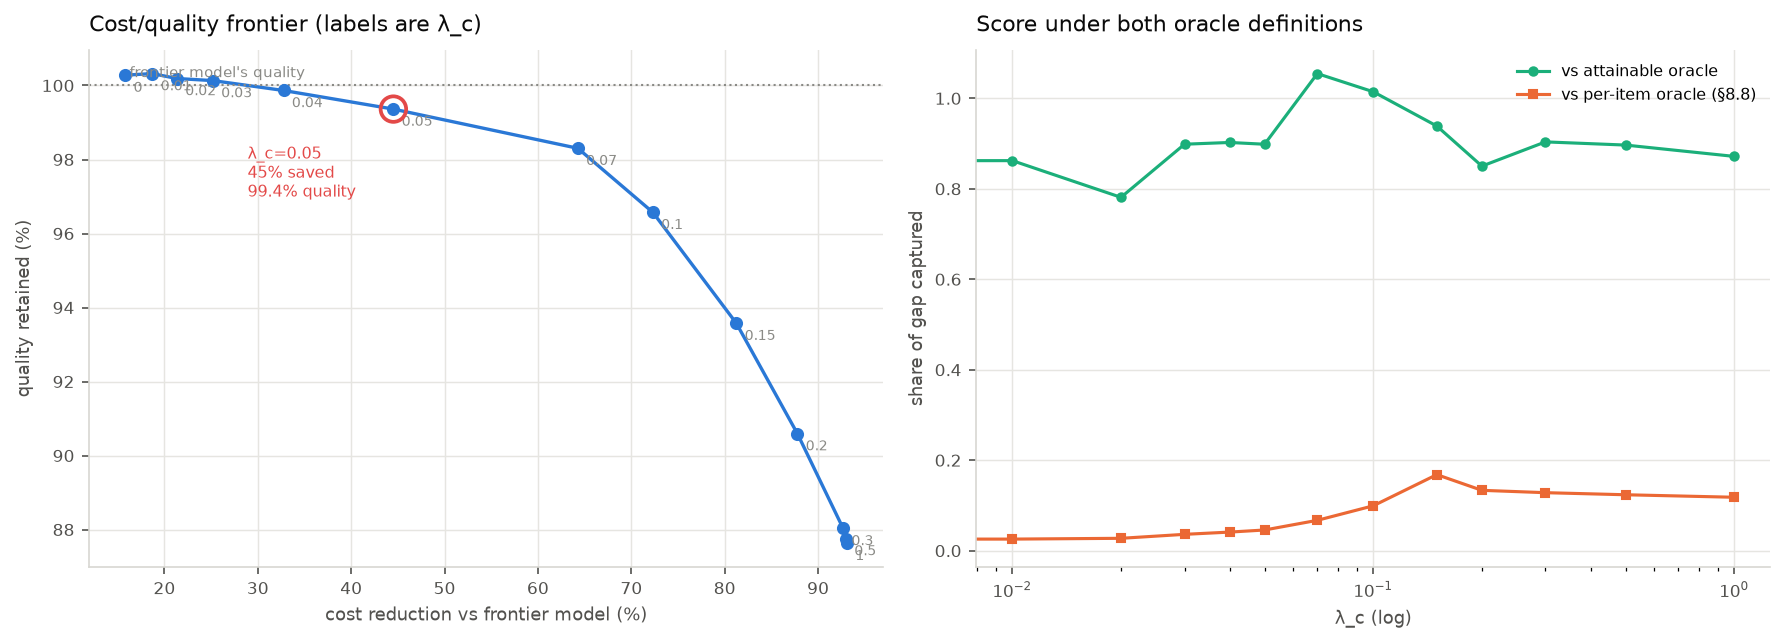

*Left: every operating point, labelled with its λ_c. Right: the same policies scored against both oracle definitions — the attainable per-task oracle and §8.8's per-item one.*

In [3]:
show("02_frontier",
     "Left: every operating point, labelled with its λ_c. Right: the same policies scored "
     "against both oracle definitions — the attainable per-task oracle and §8.8's per-item one.")

In [4]:
op = sw.loc[(sw["lam_cost"] - 0.05).abs().idxmin()]
cheap40 = sw.iloc[(sw["savings_vs_frontier"] - 0.40).abs().idxmin()]
md(f"""
At **λ_c = {op['lam_cost']:g}** the router spends **${op['cost_usd']:.2f}** where sending
everything to the frontier model costs **${op['cost_usd']/(1-op['savings_vs_frontier']):.2f}** —
a **{pct(op['savings_vs_frontier'])} cost reduction** while delivering
**{pct(op['quality_vs_frontier'])}** of that model's measured quality, on
{int(load('manifest')['n_test']):,} held-out items it never saw during fitting.
""")
finding("supported",
        f"The frontend's headline — a ~40% cut on everyday traffic — is met and slightly "
        f"exceeded: {pct(cheap40['savings_vs_frontier'])} cheaper at "
        f"{pct(cheap40['quality_vs_frontier'])} of frontier quality. Pushed harder, "
        f"{pct(sw.iloc[-4]['savings_vs_frontier'])} cheaper is available at "
        f"{pct(sw.iloc[-4]['quality_vs_frontier'])} quality.")


At **λ_c = 0.05** the router spends **$20.86** where sending
everything to the frontier model costs **$37.60** —
a **44.5% cost reduction** while delivering
**99.4%** of that model's measured quality, on
11,497 held-out items it never saw during fitting.


> **SUPPORTED** — The frontend's headline — a ~40% cut on everyday traffic — is met and slightly exceeded: 44.5% cheaper at 99.4% of frontier quality. Pushed harder, 87.8% cheaper is available at 90.6% quality.

## Against every alternative, including the ones that make it look worse

A savings figure means nothing without the controls. `random` shows how much of the gap
comes from merely not always picking the dearest model. `per-task table` is a strong
non-ML baseline — one lookup table of best-model-per-benchmark, learned on the training
split — and a router that cannot beat it is not worth its complexity.

In [5]:
pol = pd.DataFrame(fr["policies"])
view = pol[["policy", "kind", "quality", "cost_usd", "savings_vs_frontier",
            "utility", "score_spec", "score_feasible", "models_used"]].copy()
view.columns = ["policy", "kind", "quality", "cost $", "saved", "utility",
                "score (§8.8)", "score (attainable)", "models"]
view.style.format({"quality": "{:.4f}", "cost $": "${:.2f}", "saved": "{:.1%}",
                   "utility": "{:.4f}", "score (§8.8)": "{:.3f}",
                   "score (attainable)": "{:+.3f}"})

,policy,kind,quality,cost $,saved,utility,score (§8.8),score (attainable),models
0,random,control,0.5197,$9.48,74.8%,0.5060,0.000,-24.244,11
1,best single (utility),baseline,0.7782,$37.60,0.0%,0.7282,0.000,+0.000,1
2,frontier only,baseline,0.7782,$37.60,0.0%,0.7282,0.000,+0.000,1
3,per-task table (train),baseline,0.7665,$14.84,60.5%,0.7305,0.013,+0.253,7
4,router: quality only,router,0.7803,$31.65,15.8%,0.7352,0.039,+0.764,10
5,router: §8 ridge+LinUCB,router,0.7732,$20.86,44.5%,0.7364,0.046,+0.899,10
6,oracle: per-task (feasible),ceiling,0.7800,$27.76,26.2%,0.7373,0.051,+1.000,8
7,oracle: per-item (§8.8),ceiling,0.9121,$2.71,92.8%,0.9082,1.000,+19.645,11


In [6]:
r = pol.set_index("policy")
router = r.loc["router: §8 ridge+LinUCB"]
tbl = r.loc["per-task table (train)"]
qonly = r.loc["router: quality only"]
md(f"""
- The router captures **{router['score_feasible']:.1%}** of the gap between the best
  single model and the best attainable per-task assignment.
- It beats the per-task lookup table ({tbl['score_feasible']:.1%}) — so the per-item
  signal in the prompt is real, not just benchmark identity in disguise.
- With the cost term switched off it reaches {qonly['quality']:.4f} quality, *above* the
  frontier model's own {r.loc['frontier only']['quality']:.4f}, at
  {pct(qonly['savings_vs_frontier'])} of the saving. Routing improves quality and cost
  along different axes, and λ_c is how you choose between them.
""")
finding("supported",
        f"Routing beats the best single model on cost at near-equal quality, and beats a "
        f"strong non-ML baseline. AC-1's *direction* holds. Its threshold does not — see below.")


- The router captures **89.9%** of the gap between the best
  single model and the best attainable per-task assignment.
- It beats the per-task lookup table (25.3%) — so the per-item
  signal in the prompt is real, not just benchmark identity in disguise.
- With the cost term switched off it reaches 0.7803 quality, *above* the
  frontier model's own 0.7782, at
  15.8% of the saving. Routing improves quality and cost
  along different axes, and λ_c is how you choose between them.


> **SUPPORTED** — Routing beats the best single model on cost at near-equal quality, and beats a strong non-ML baseline. AC-1's *direction* holds. Its threshold does not — see below.

## Where AC-1 cannot be met, and why that is the metric's fault

AC-1 asks for normalised regret below 0.6. The `regret (§8.8)` column never comes close:
the best operating point sits near 0.9. That is not the router failing.

§8.8 defines the oracle as the argmax of *realised* outcomes per item. On binary grading
that argmax banks luck. Notebook 05 measures the consequence — about **half** the
oracle-to-baseline gap is unreachable by any policy — and shows that a clairvoyant
per-task oracle also scores near zero under the same definition. A threshold no
achievable policy can reach is a threshold about the metric, not about the router.

The `score (attainable)` column is the same quantity measured against a ceiling a policy
could actually hit, and there the router reads 0.7–0.9 depending on the dial.

In [7]:
man = load("manifest")
md(f"""
### Cost of running the thing

| | |
|---|---|
| feature dimension d | {man['feature_dim']} |
| policy artifact | {sw.iloc[0]['artifact_kb']:.0f} KB |
| fit | one pass, seconds, CPU only |
| update per observation | O(d²) ≈ 4,000 flops |
| GPU | none, at fit or serve time |

§8.9's claims about size and cost hold. The artifact is larger than the ~210 KB the
document quotes, for a reason worth knowing: that budget assumes one Gram matrix per
model shared across all three prediction targets, and giving quality and token-count
their own decay rates — Contribution 1 — makes them two matrices instead of one.
Notebook 06 returns to this.
""")


### Cost of running the thing

| | |
|---|---|
| feature dimension d | 64 |
| policy artifact | 358 KB |
| fit | one pass, seconds, CPU only |
| update per observation | O(d²) ≈ 4,000 flops |
| GPU | none, at fit or serve time |

§8.9's claims about size and cost hold. The artifact is larger than the ~210 KB the
document quotes, for a reason worth knowing: that budget assumes one Gram matrix per
model shared across all three prediction targets, and giving quality and token-count
their own decay rates — Contribution 1 — makes them two matrices instead of one.
Notebook 06 returns to this.
